In [8]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import xml.etree.ElementTree as ET
import os
import pandas as pd

HOME = os.path.abspath(os.sep)
train_dataset_folder = os.getcwd() + "/Dataset/fasterrcnn/train"
valid_dataset_folder = os.getcwd() + "/Dataset/fasterrcnn/valid"

In [9]:

import json
from torch.utils.data import Dataset

class GunDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, transform=None, train=True):
      with open(annotation_dir, "r") as f:
        coco_data = json.load(f)
      self.image_dir = image_dir
      self.transform = transform
      self.train = train
      self.images = coco_data['images']
      self.annotations = coco_data['annotations']
      self.classes = {"gun": 0}
      
            # Crea il mapping immagine -> annotazioni
      self.img_to_anns = {img['id']: [] for img in self.images}
      for ann in self.annotations:
        self.img_to_anns[ann['image_id']].append(ann)
    
      print(f"Immagini totali: {len(self.images)}")
      print(f"Immagini con annotazioni: {len(self.images)}")
      
    def __len__(self):
        return len(self.images)
      
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, str(self.images[idx]['file_name']))
        image = Image.open(image_path).convert("RGB")
        
        # Ottieni le annotazioni per questa immagine
        img_id = self.images[idx]['id']
        annotations = self.img_to_anns[img_id]
        
        # Prepara boxes e labels per tutte le annotazioni di questa immagine
        boxes = []
        labels = []
        
        for ann in annotations:
            # Le box COCO sono in formato [x, y, width, height]
            # Convertiamo in [x1, y1, x2, y2]
            box = ann['bbox']
            x, y, w, h = box
            boxes.append([x, y, x + w, y + h])
            labels.append(ann['category_id'])
        
        # Converti in tensori
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Applica le trasformazioni all'immagine
        if self.transform is not None:
            image = self.transform(image)
            
        return image, boxes, labels
        

In [10]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = GunDataset(train_dataset_folder, train_dataset_folder+"/_annotations.coco.json", transform=transform)
val_dataset = GunDataset(valid_dataset_folder, valid_dataset_folder+"/_annotations.coco.json", transform=transform)

num_workers = 2 
if os.name == 'nt':
    num_workers = 0
    
def collate_fn(batch):
    return tuple(zip(*batch))

# Modifica i DataLoader per usare la funzione di collate personalizzata
train_loader = DataLoader(
    train_dataset, 
    batch_size=4, 
    shuffle=True, 
    num_workers=num_workers,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=4, 
    shuffle=False, 
    num_workers=num_workers,
    collate_fn=collate_fn
)

Immagini totali: 6205
Immagini con annotazioni: 6205
Immagini totali: 594
Immagini con annotazioni: 594


In [11]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.nn as nn

model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

in_features = model.roi_heads.box_predictor.cls_score.in_features

class FasterRCNNPredictorWithDropout(nn.Module):
  def __init__(self, in_channels, num_classes, dropout_prob=0.4):
    super(FasterRCNNPredictorWithDropout, self).__init__()
    self.dropout = nn.Dropout(p=dropout_prob)
    self.cls_score = nn.Linear(in_channels, num_classes)
    self.bbox_pred = nn.Linear(in_channels, num_classes*4)
    
  def forward(self, x):
    x = self.dropout(x)
    scores = self.cls_score(x)
    bbox_deltas = self.bbox_pred(x)
    return scores, bbox_deltas

# Rimpiazziamo il classificatore con uno nuovo per il gun detection
model.roi_heads.box_predictor = FasterRCNNPredictorWithDropout(in_features, num_classes=2, dropout_prob=0.4)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr = 0.0025, momentum=0.9, weight_decay=0.002)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [12]:
from torchmetrics.detection import MeanAveragePrecision
import time

def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0
    loss_classifier = 0
    loss_box_reg = 0
    loss_objectness = 0
    loss_rpn_box_reg = 0
    
    # Inizializza metric calculator con IoU thresholds simili a YOLO
    metric = MeanAveragePrecision(box_format='xyxy', 
                                 iou_thresholds=[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])
    
    print(f"Epoch: {epoch+1}")
    start_time = time.time()
    
    for i, (images, targets_boxes, targets_labels) in enumerate(data_loader):
        images = list(image.to(device) for image in images)
        targets = []
        
        # Formatta i target come richiesto da Faster R-CNN
        for boxes, labels in zip(targets_boxes, targets_labels):
            target = {}
            target['boxes'] = boxes.to(device)
            target['labels'] = labels.to(device)
            targets.append(target)
        
        # Forward pass e calcolo loss
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Accumula le loss individuali per il reporting
        loss_classifier += loss_dict.get('loss_classifier', 0)
        loss_box_reg += loss_dict.get('loss_box_reg', 0)
        loss_objectness += loss_dict.get('loss_objectness', 0)
        loss_rpn_box_reg += loss_dict.get('loss_rpn_box_reg', 0)
        
        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
        
        # Ottieni le predizioni
        model.eval()
        with torch.no_grad():
            predictions = model(images)
        model.train()
        
        # Aggiorna le metriche
        metric.update(predictions, targets)
        
        if i % 50 == 0:  # Log ogni 50 batch
            print(f"Batch [{i}/{len(data_loader)}], Loss: {losses.item():.4f}")
    
    # Calcola le metriche finali
    metric_results = metric.compute()
    
    # Estrai le metriche principali
    metrics = {
        'loss': total_loss / len(data_loader),
        'loss_classifier': loss_classifier / len(data_loader),
        'loss_box_reg': loss_box_reg / len(data_loader),
        'loss_objectness': loss_objectness / len(data_loader),
        'loss_rpn_box_reg': loss_rpn_box_reg / len(data_loader),
        'mAP': metric_results['map'].item(),
        'mAP_50': metric_results['map_50'].item(),
        'mAP_75': metric_results['map_75'].item(),
    }
    
    print(f"\nEpoch {epoch+1} training results:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    
    print(f"Time taken: {time.time() - start_time:.2f} seconds")
    
    return metrics

def validate(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision(box_format='xyxy', 
                                 iou_thresholds=[0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])
    total_val_loss = 0
    
    with torch.no_grad():
        for images, targets_boxes, targets_labels in data_loader:
            images = list(image.to(device) for image in images)
            targets = []
            
            for boxes, labels in zip(targets_boxes, targets_labels):
                target = {}
                target['boxes'] = boxes.to(device)
                target['labels'] = labels.to(device)
                targets.append(target)
                
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            total_val_loss += losses.item()
            
            predictions = model(images)
            metric.update(predictions, targets)
    
    metric_results = metric.compute()
    
    metrics = {
        'val_mAP': metric_results['map'].item(),
        'val_mAP_50': metric_results['map_50'].item(),
        'val_mAP_75': metric_results['map_75'].item(),
        'val_loss': total_val_loss / len(data_loader),
    }
    
    print("\nValidation results:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    
    return metrics

# Funzione principale di training
def train_model(model, optimizer, scheduler, train_loader, val_loader, device, num_epochs=10):
    best_map = 0
    history = []
    
    #Early stopping
    patience = 3  # Numero di epoche da attendere prima di fermarsi se non ci sono miglioramenti
    epochs_no_improve = 0
    best_model_path = 'best_model_fasterrcnn_dropout.pth'
    
    for epoch in range(num_epochs):
        # Training
        train_metrics = train_one_epoch(model, optimizer, train_loader, device, epoch)
        
        # Validation
        val_metrics = validate(model, val_loader, device)
        
        # Update learning rate
        scheduler.step()
        
        # Save best model
        if val_metrics['val_mAP'] > best_map:
            best_map = val_metrics['val_mAP']
            torch.save(model.state_dict(), best_model_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"Nessun miglioramento per {epochs_no_improve} epoche. Miglior mAP: {best_map:.4f}")
            
        # Early stopping
        if epochs_no_improve >= patience:
            print(f"Early stopping attivato all'epoca {epoch+1}")
            break
        
        # Combine metrics and save history
        epoch_metrics = {**train_metrics, **val_metrics}
        history.append(epoch_metrics)
        
        print(f"Epoca {epoch+1}/{num_epochs} completata")
        print("-" * 50)
    
    return history

In [13]:
def plot_metrics(history):
    # Crea un DataFrame per una migliore gestione dei dati
    df = pd.DataFrame(history)
    
    # Definisci le metriche da visualizzare
    metrics_to_plot = [
        ('mAP', 'val_mAP', 'Mean Average Precision'),
        ('mAP_50', 'val_mAP_50', 'mAP@0.5'),
        ('loss', None, 'Training Loss'),
    ]
    
    # Crea una figura con sottografici
    fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 4*len(metrics_to_plot)))
    
    for i, (train_metric, val_metric, title) in enumerate(metrics_to_plot):
        ax = axes[i]
        
        # Plot della metrica di training
        if train_metric in df.columns:
            ax.plot(df.index, df[train_metric], 'b-', label=f'Training {title}')
        
        # Plot della metrica di validazione se disponibile
        if val_metric and val_metric in df.columns:
            ax.plot(df.index, df[val_metric], 'r-', label=f'Validation {title}')
            
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.savefig('training_metrics_dropout.png')
    plt.show()

Epoch: 1
Batch [0/1552], Loss: 1.8067
Batch [50/1552], Loss: 0.1061
Batch [100/1552], Loss: 0.1525
Batch [150/1552], Loss: 0.1207
Batch [200/1552], Loss: 0.2157
Batch [250/1552], Loss: 0.2026
Batch [300/1552], Loss: 0.1024
Batch [350/1552], Loss: 0.1031
Batch [400/1552], Loss: 0.0632
Batch [450/1552], Loss: 0.1255
Batch [500/1552], Loss: 0.1997
Batch [550/1552], Loss: 0.2369
Batch [600/1552], Loss: 0.0563
Batch [650/1552], Loss: 0.1374
Batch [700/1552], Loss: 0.1477
Batch [750/1552], Loss: 0.0894
Batch [800/1552], Loss: 0.2229
Batch [850/1552], Loss: 0.1090
Batch [900/1552], Loss: 0.1856
Batch [950/1552], Loss: 0.1655
Batch [1000/1552], Loss: 0.1029
Batch [1050/1552], Loss: 0.1512
Batch [1100/1552], Loss: 0.1425
Batch [1150/1552], Loss: 0.0878
Batch [1200/1552], Loss: 0.0880
Batch [1250/1552], Loss: 0.0809
Batch [1300/1552], Loss: 0.0751
Batch [1350/1552], Loss: 0.1164
Batch [1400/1552], Loss: 0.0715
Batch [1450/1552], Loss: 0.0724
Batch [1500/1552], Loss: 0.0952
Batch [1550/1552], Los

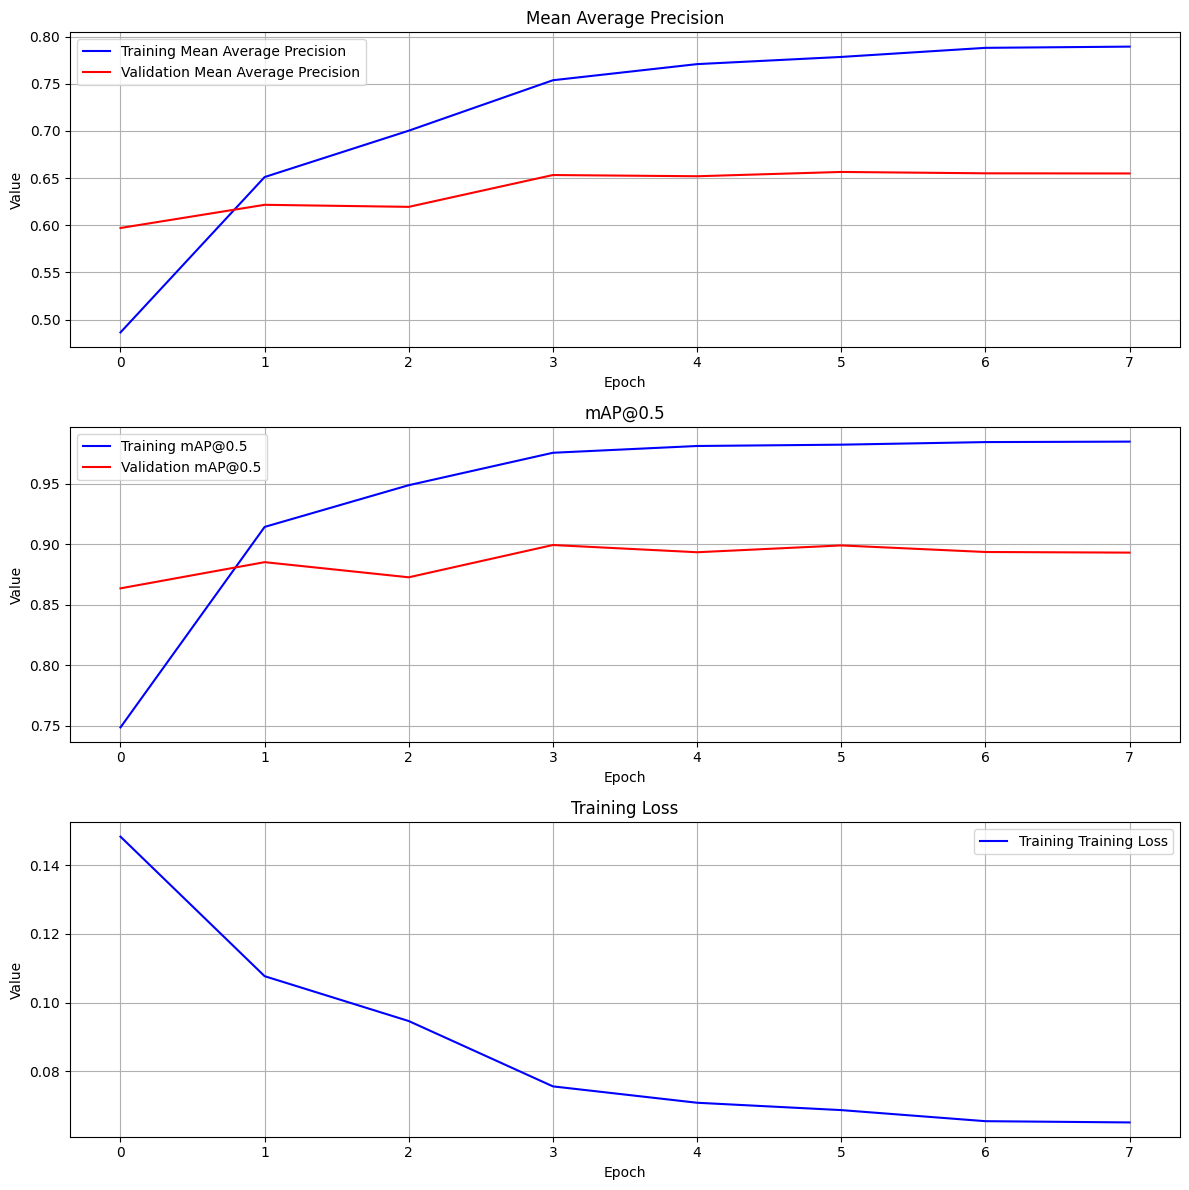

In [14]:
num_epochs = 20
history = train_model(model, optimizer, lr_scheduler, train_loader, val_loader, device, num_epochs)
plot_metrics(history)